# 📄 OCR Demonstration with Fixed Samples and Structured Validation

---

## 🎯 Overview

This notebook presents a **complete, end-to-end OCR (Optical Character Recognition) pipeline** using modern Vision-Language Models (VLMs).

This notebook is carefully designed to:

- Apply **Vision-Language Models (Qwen-VL)** for text extraction
- Perform **structured validation against manually annotated ground truth**
- Demonstrate how OCR can be evaluated in **real business scenarios**

---

## 💡 Motivation

In real-world business applications such as:

- Invoice processing  
- Financial document analysis  
- Handwritten form digitization  

---

## 📥📤 Global Input and Output of This Notebook

### 📥 Input

The notebook takes the following inputs:

1. **Document Images (Fixed Samples)**
   - Invoice document  
   - Budget table  
   - Handwritten note  

2. **Ground Truth (Manually Annotated for Validation Purpose)**
   - Full document transcription  
   - Key business fields (e.g., total amount, cost)

3. **OCR Model (Qwen-VL-Max)**
   - Vision-language model for extracting text from images

---

### 📤 Output

The notebook produces:

1. **OCR Extracted Text**
   - Raw text extracted from each document

2. **Validation Results**
   - Exact match checks  
   - Regex-based field extraction  
   - Field-level correctness validation  

3. **Structured Evaluation Summary**
   - Whether each document passes validation  
   - Which fields are correct / incorrect  

4. **Side-by-Side Comparison**
   - OCR output vs ground truth  
   - Helps visually understand OCR errors  

---



## 🔄 End-to-End Pipeline (Conceptual Flow)

    ┌────────────────────────────┐
    │   Document Images (Input)  │
    │  (Invoice / Budget / Note) │
    └────────────┬───────────────┘
                 │
                 ▼
    ┌────────────────────────────┐
    │   Vision-Language Model    │
    │       (Qwen-VL-Max)        │
    └────────────┬───────────────┘
                 │
                 ▼
    ┌────────────────────────────┐
    │   Extracted Text (OCR)     │
    └────────────┬───────────────┘
                 │
                 ▼
    ┌────────────────────────────┐
    │   Validation Layer         │
    │  - Exact Match             │
    │  - Regex Extraction        │
    │  - Field Checking          │
    └────────────┬───────────────┘
                 │
                 ▼
    ┌────────────────────────────┐
    │   Evaluation Results       │
    │  - Pass / Fail             │
    │  - Field Accuracy          │
    └────────────┬───────────────┘
                 │
                 ▼
    ┌────────────────────────────┐
    │   Final Summary & Report   │
    └────────────────────────────┘

## 🧠 Key Learning Objectives

By the end of this notebook, you should be able to:

1. Understand how modern **Vision-Language Models perform OCR**
2. Build a **reproducible OCR pipeline** using fixed samples
3. Design **structured validation logic** for business documents
4. Evaluate OCR quality beyond simple text extraction
5. Connect OCR outputs to **real-world decision-making scenarios**

---

## 🚀 What You Will See Next

The notebook proceeds in 6 structured steps:

1. Environment setup  
2. Import and configuration  
3. Dataset loading  
4. Fixed sample selection and visualization  
5. OCR extraction  
6. Validation and summary  

Each step is designed to be:
- **Self-contained**
- **Clearly explained**
- **Directly runnable**

---

# Step 1 — Environment Setup and Package Installation

## What this block does

This block prepares the Colab runtime before any OCR logic starts. In a cloud notebook, the runtime is temporary, which means external packages may not already be available when the notebook opens. Because of that, the very first step should isolate environment preparation from the rest of the pipeline.

This block installs all third-party libraries that the later steps depend on. The goal is not only to make the notebook runnable, but also to make the notebook **re-runnable**. If a student restarts the runtime and executes the notebook from top to bottom, this block ensures that the required libraries are restored in a consistent way before imports, image loading, OCR calls, or validation begin.

## Why this block is important

If package installation is mixed into later business logic, debugging becomes confusing. For example, if an OCR cell fails, it may be unclear whether the problem came from a missing package, a path issue, or the OCR call itself. By keeping setup in its own block, the rest of the notebook becomes easier to interpret.

## Mini flow diagram

```text
Fresh Colab runtime
        ↓
Install required packages
        ↓
Runtime becomes ready
        ↓
Later blocks can focus only on OCR logic
```


In [1]:
# ============================================================
# CELL 1 OF 6 — SETUP AND PACKAGE INSTALLATION
# ============================================================
# This cell prepares the runtime so the rest of the notebook
# can run in a clean and reproducible way inside Google Colab.
#
# Overall purpose of this cell:
# 1. Install all external Python packages used later.
# 2. Keep the installation step isolated from the analysis logic.
# 3. Make the notebook easy to rerun from top to bottom.
#
# Packages installed here:
# - requests: sends HTTP requests to the OCR API
# - pillow: loads and manipulates document images
# - pandas: builds summary tables
# - matplotlib: previews document images
# - kagglehub: downloads the RVL-CDIP sample dataset
#
# Every command below is intentionally kept simple so students
# can understand exactly what is being installed.

# Install the HTTP client library used for calling the OCR API.
!pip -q install requests

# Install Pillow so the notebook can open and display image files.
!pip -q install pillow

# Install pandas so the notebook can create validation summary tables.
!pip -q install pandas

# Install matplotlib so the notebook can preview the fixed document images.
!pip -q install matplotlib

# Install kagglehub so the notebook can download the dataset in Colab.
!pip -q install kagglehub


# Step 2 — Imports, Global Configuration, and Helper Utilities

## What this block does

This block centralizes the notebook's core dependencies and global settings. After the environment is prepared, the next step is to import every library that will be used later and define the small helper functions that keep the rest of the notebook readable.

This block also defines the OCR API configuration in one place. That design is important because the OCR pipeline later depends on the same endpoint, the same model name, and the same authentication settings. Keeping those values centralized avoids repetition and makes the later code easier to maintain.

In addition, this block creates a few small helper functions for formatting console output and normalizing text. These helpers are not the “main work” of the notebook, but they make the workflow cleaner, more interpretable, and easier to debug.

## Why this block is important

Without a central configuration block, later cells often become cluttered with repeated constants, repeated imports, and inconsistent string handling. This notebook is meant to be instructional, so the structure should make it obvious where to find:

- imported libraries,
- API settings,
- formatting helpers, and
- shared utility functions.

## Mini flow diagram

```text
Prepared runtime
        ↓
Import libraries
        ↓
Define global API settings
        ↓
Define helper utilities
        ↓
All later blocks can stay cleaner
```

In [2]:
# ============================================================
# CELL 2 OF 6 — IMPORTS, GLOBAL CONFIGURATION, AND SMALL UTILITIES
# ============================================================
# This cell centralizes all imports and all global settings.
#
# Overall purpose of this cell:
# 1. Import every library used later in the notebook.
# 2. Define the hard-coded API configuration exactly once.
# 3. Provide tiny helper utilities for clean console output.
#
# Important note:
# The API key below is intentionally hard-coded because this
# notebook is being used in your Colab workflow exactly that way.

# Import os so the notebook can work with directory paths.
import os

# Import io so the notebook can store temporary image bytes in memory.
import io

# Import re so the notebook can normalize and compare text.
import re

# Import base64 so the notebook can encode images before sending them to the OCR API.
import base64

# Import json so the notebook can build the OCR request payload clearly.
import json

# Import requests so the notebook can send HTTP POST requests to the OCR endpoint.
import requests

# Import Path so file paths can be handled safely across the notebook.
from pathlib import Path

# Import Image so the notebook can open TIFF document images.
from PIL import Image

# Import pyplot so the notebook can preview the selected document images.
import matplotlib.pyplot as plt

# Import pandas so the notebook can summarize validation results in table form.
import pandas as pd

# Import SequenceMatcher so the notebook can compute a simple text similarity score.
from difflib import SequenceMatcher

# Import kagglehub so the notebook can download the RVL-CDIP sample dataset.
import kagglehub

# Store the hard-coded API key used by the OCR service.
API_KEY = "sk-cJvvaaDosK2UQKWvPeyK7HyrRK004ul6L9IN7YdZm00cd7xT"

# Store the full chat-completions endpoint used by the Qwen-compatible OCR API.
BASE_URL = "https://api.bianxie.ai/v1/chat/completions"

# Define a small helper that prints a clean visual title in the output.
def print_section(title):
    # Print a blank line first so the section title is easier to read.
    print("\n" + "=" * 100)
    # Print the title text itself.
    print(title)
    # Print a closing separator line.
    print("=" * 100)

# Define a helper that normalizes text for more tolerant validation.
def normalize_text(text):
    # Convert the input to string in case a non-string value is passed accidentally.
    text = str(text)
    # Convert the text to lowercase so matching is case-insensitive.
    text = text.lower()
    # Replace line breaks and tabs with spaces so formatting differences matter less.
    text = re.sub(r"\s+", " ", text)
    # Remove repeated spaces from the normalized text.
    text = re.sub(r"\s+", " ", text).strip()
    # Return the cleaned text.
    return text

# Define a helper that normalizes numeric strings by removing commas and spaces.
def normalize_number(text):
    # Convert the input value to string so the same logic works for any numeric-like value.
    text = str(text)
    # Remove commas because OCR may or may not preserve thousand separators.
    text = text.replace(",", "")
    # Remove spaces around the value.
    text = text.strip()
    # Return the normalized numeric string.
    return text


# Step 3 — Dataset Download and Fixed-Sample Registration

## What this block does

This block performs two connected tasks.

First, it downloads the RVL-CDIP sample dataset into the active Colab session. Since Colab does not keep files permanently across sessions, the dataset path needs to be obtained dynamically during execution.

Second, this block defines the **fixed validation samples** used in the rest of the notebook.

The three document types are:

- invoice,
- budget,
- handwritten letter.

Each one has a different OCR difficulty profile, so together they make the demonstration more instructive.

## Why this block is important

A strong validation pipeline requires known reference targets. By fixing the files in advance, this block makes the downstream evaluation meaningful. The OCR result can now be compared against:

1. a full manually prepared text reference, and
2. specific key business fields, such as totals, dates, and names.

## Mini flow diagram

```text
Kaggle dataset
      ↓
Download into Colab
      ↓
Obtain local dataset path
      ↓
Register fixed file names
      ↓
Attach ground truth + key fields
```



In [3]:
# ============================================================
# CELL 3 OF 6 — DOWNLOAD THE DATASET AND DEFINE THE FIXED VALIDATION SAMPLES
# ============================================================
# This cell does two major jobs.
#
# Job A:
# Download the RVL-CDIP sample dataset into the current Colab runtime.
#
# Job B:
# Register the three fixed files, together with their manually prepared
# ground truth and their field-level validation targets.
#
# The three fixed files used in this notebook are:
# - invoice:     2028719911.tif
# - budget:      96343804.tif
# - handwritten: 500022678.tif

# Define a function that downloads the RVL-CDIP sample dataset and returns its local path.
def download_rvl_cdip_dataset():
    # Print a visible section title so the output is easier to read.
    print_section("STEP 1 — DOWNLOAD DATASET")
    # Wrap the download in a try/except block so failures are reported clearly.
    try:
        # Download the exact dataset version needed for this notebook.
        dataset_path = kagglehub.dataset_download("uditamin/rvl-cdip-small/versions/1")
        # Print the downloaded dataset path.
        print(f"✅ Dataset downloaded to: {dataset_path}")
        # Return the dataset path for later use.
        return dataset_path
    # Catch any unexpected error raised during the dataset download.
    except Exception as e:
        # Print a readable error message.
        print(f"❌ Failed to download dataset: {e}")
        # Re-raise the error so the notebook stops instead of silently continuing.
        raise

# Download the dataset and store the returned local path.
dataset_path = download_rvl_cdip_dataset()

# Define the complete fixed-sample manifest used by the rest of the notebook.
FIXED_SAMPLE_MANIFEST = [
    {
        # Store a stable internal identifier for the invoice sample.
        "sample_id": "invoice_sample",
        # Store the category label of the sample.
        "category": "invoice",
        # Store the exact file name that must be found recursively in the dataset.
        "file_name": "2028719911.tif",
        # Store the display title shown in reports.
        "display_title": "Invoice Document - 2028719911.tif",
        # Store the manually prepared full-text ground truth for this image.
        "ground_truth_text": """INBIFO Institut für biologische Forschung GmbH
                                Kaufmännische Verwaltung

                                CRC Contract Research Center B.V.B.A.
                                Tolaan 101c
                                B-1932 Zaventem, St.-Stevens-Woluwe

                                AEB/IBM PF.WM
                                Köln, 21.Okt.92

                                PROFORMA-RECHNUNG
                                Nr.: 48/92
                                Bei Zahlung bitte angeben

                                Betr.: Rücksendung nach Überprüfung

                                Wir senden Ihnen nach kostenloser Überprüfung
                                folgende Geräte durch unseren Mitarbeiter,
                                Herrn U. Mühler, zurück:

                                1 Stück Rauchmaschine Typ SM 85-9
                                Waren-Nr. 847810000

                                4 Stück Inhalationskammern Typ 48
                                DM 1.000,--/Stück =
                                Waren-Nr. 847810000

                                WERT NUR FÜR
                                ZOLLZWECKE
                                BESTIMMT!

                                1.000,--
                                4.000,--
                                TOTAL
                                5.000,--

                                Lieferung ab Köln, Transportversicherung ist
                                durch uns gedeckt.

                                Zollabfertigung durch die Spedition Ziegler S.A.
                                B-Eynatten.

                                PROFORMA-RECHNUNG NUR FÜR ZOLLZWECKE BESTIMMT!""",
        # Store field-level targets that are especially important for the invoice example.
        "target_fields": {
            "document_number": "2028719911",
            "document_type": "PROFORMA-RECHNUNG",
            "customer_name": "CRC Contract Research Center B.V.B.A.",
            "total_amount": "5.000,--"
        }
    },
    {
        # Store a stable internal identifier for the budget sample.
        "sample_id": "budget_sample",
        # Store the category label of the sample.
        "category": "budget",
        # Store the exact file name that must be found recursively in the dataset.
        "file_name": "96343804.tif",
        # Store the display title shown in reports.
        "display_title": "Budget Document - 96343804.tif",
        # Store the manually prepared full-text ground truth for this image.
        "ground_truth_text": """NEWPORT
                                BUDGET BY MEDIA
                                1992

                                $000

                                OUTDOOR 27,457
                                TRANSIT 963
                                MAGAZINES 10,858*
                                BLACK MAGAZINES 1,465
                                BLACK OUTDOOR 6,127
                                BLACK TRANSIT 1,214
                                HISPANIC OUTDOOR 634
                                HISPANIC TRANSIT 316

                                TOTAL MEDIA 49,034
                                PROD: COMM. 1,850
                                PROD: NON-COMM. 254

                                TOTAL MEDIA & PROD. 51,138
                                AGENCY FEE 3,907
                                TOTAL AGENCY 55,045
                                CORPORATE MEDIA 1,286
                                CORPORATE PRODUCTION 3,339
                                TOTAL ADVERTISING 59,670

                                /bm
                                064.MMO/ATT./PAN2

                                6/19/92 Rev. #2 - Revised to reflect addition of $400M to fund
                                Slim Lights Introduction.

                                * Excludes Corporate Credits""",
        # Store field-level targets that are especially important for the budget example.
        "target_fields": {
            "document_type": "BUDGET BY MEDIA",
            "year": "1992",
            "total_media": "$49,034",
            "total_agency": "$55,045",
            "total_advertising": "$59,670"
        }
    },
    {
        # Store a stable internal identifier for the handwritten sample.
        "sample_id": "handwritten_sample",
        # Store the category label of the sample.
        "category": "handwritten",
        # Store the exact file name that must be found recursively in the dataset.
        "file_name": "500022678.tif",
        # Store the display title shown in reports.
        "display_title": "Handwritten Document - 500022678.tif",
        # Store the manually prepared full-text ground truth for this image.
        "ground_truth_text": 'R. J. Reynolds Tobacco Company\nWinston-Salem, N.C.\n\n2? John Parkway Lane\nWilliamsburg, Va. 23185\nNovember 3, 1966\n\nDear Sirs:\n\nOn the evening of Friday, November 18,\na group of about 15 high school students,\nand their Chaperones from the Williamsburg\nBaptist Church will arrive in Winston-Salem\nto spend the next day touring\nOld Salem. If you are still conducting\ntours as late as 8:30 or 9:00 p.m. we\nwould be quite interested in seeing\nyour cigarette factory on the evening of\nour arrival. Please let us know if\nsuch a tour can be arranged.\n\nThank you very much.\n\nSincerely,\nJoan H. Phillips\n(Mrs. J. T. Phillips, Jr.)\n',
        # Store field-level targets that are especially important for the handwritten example.
        "target_fields": {
            "recipient": "R. J. Reynolds Tobacco Company",
            "location": "Winston-Salem, N.C.",
            "date": "November 3, 1966",
            "closing": "Sincerely",
            "sender": "Joan H. Phillips"
        }
    }
]

# Print a short confirmation so the user can verify the notebook configuration.
print_section("STEP 2 — FIXED SAMPLE CONFIGURATION")
# Print the local dataset path that will be searched.
print(f"📁 Dataset path: {dataset_path}")
# Print the three fixed file names in the manifest.
print("📄 Fixed sample files:")
# Loop through the manifest and print one file name per line.
for item in FIXED_SAMPLE_MANIFEST:
    # Print the file name and category for each fixed sample.
    print(f"  • {item['category']} → {item['file_name']}")



STEP 1 — DOWNLOAD DATASET
Using Colab cache for faster access to the 'rvl-cdip-small' dataset.
✅ Dataset downloaded to: /kaggle/input/rvl-cdip-small

STEP 2 — FIXED SAMPLE CONFIGURATION
📁 Dataset path: /kaggle/input/rvl-cdip-small
📄 Fixed sample files:
  • invoice → 2028719911.tif
  • budget → 96343804.tif
  • handwritten → 500022678.tif


# Step 4 — Locate the Fixed Files, Load the Images, and Preview the Inputs

## What this block does

This block takes the abstract sample manifest from Step 3 and turns it into actual loaded image objects. In other words, Step 3 defined *which* files should be used, while this step actually searches the dataset, finds those files on disk, loads them into memory, and displays them for visual inspection.

This is an important bridge between metadata and actual computation. Before running OCR, it is good practice to verify the exact images being processed.

The block therefore does four things:

1. recursively search the dataset for each target file name,
2. load each matching file as a PIL image,
3. merge the image with its metadata and reference text, and
4. display the selected documents so the notebook shows the true OCR inputs.

## Why this block is important

- the invoice includes printed business fields,
- the budget includes tabular numeric structure,
- the handwritten letter introduces script-style recognition challenges.

Showing the raw image before OCR makes the later extraction results much more interpretable.

## Mini flow diagram

```text
Fixed sample manifest
        ↓
Recursive file search
        ↓
Locate exact document files
        ↓
Load images into memory
        ↓
Preview images before OCR
```



STEP 3 — LOCATE AND LOAD FIXED DOCUMENTS
✅ Loaded invoice file: /kaggle/input/rvl-cdip-small/data/invoice/2028719911.tif
✅ Loaded budget file: /kaggle/input/rvl-cdip-small/data/budget/96343804.tif
✅ Loaded handwritten file: /kaggle/input/rvl-cdip-small/data/handwritten/500022678.tif

STEP 4 — PREVIEW THE THREE FIXED DOCUMENTS


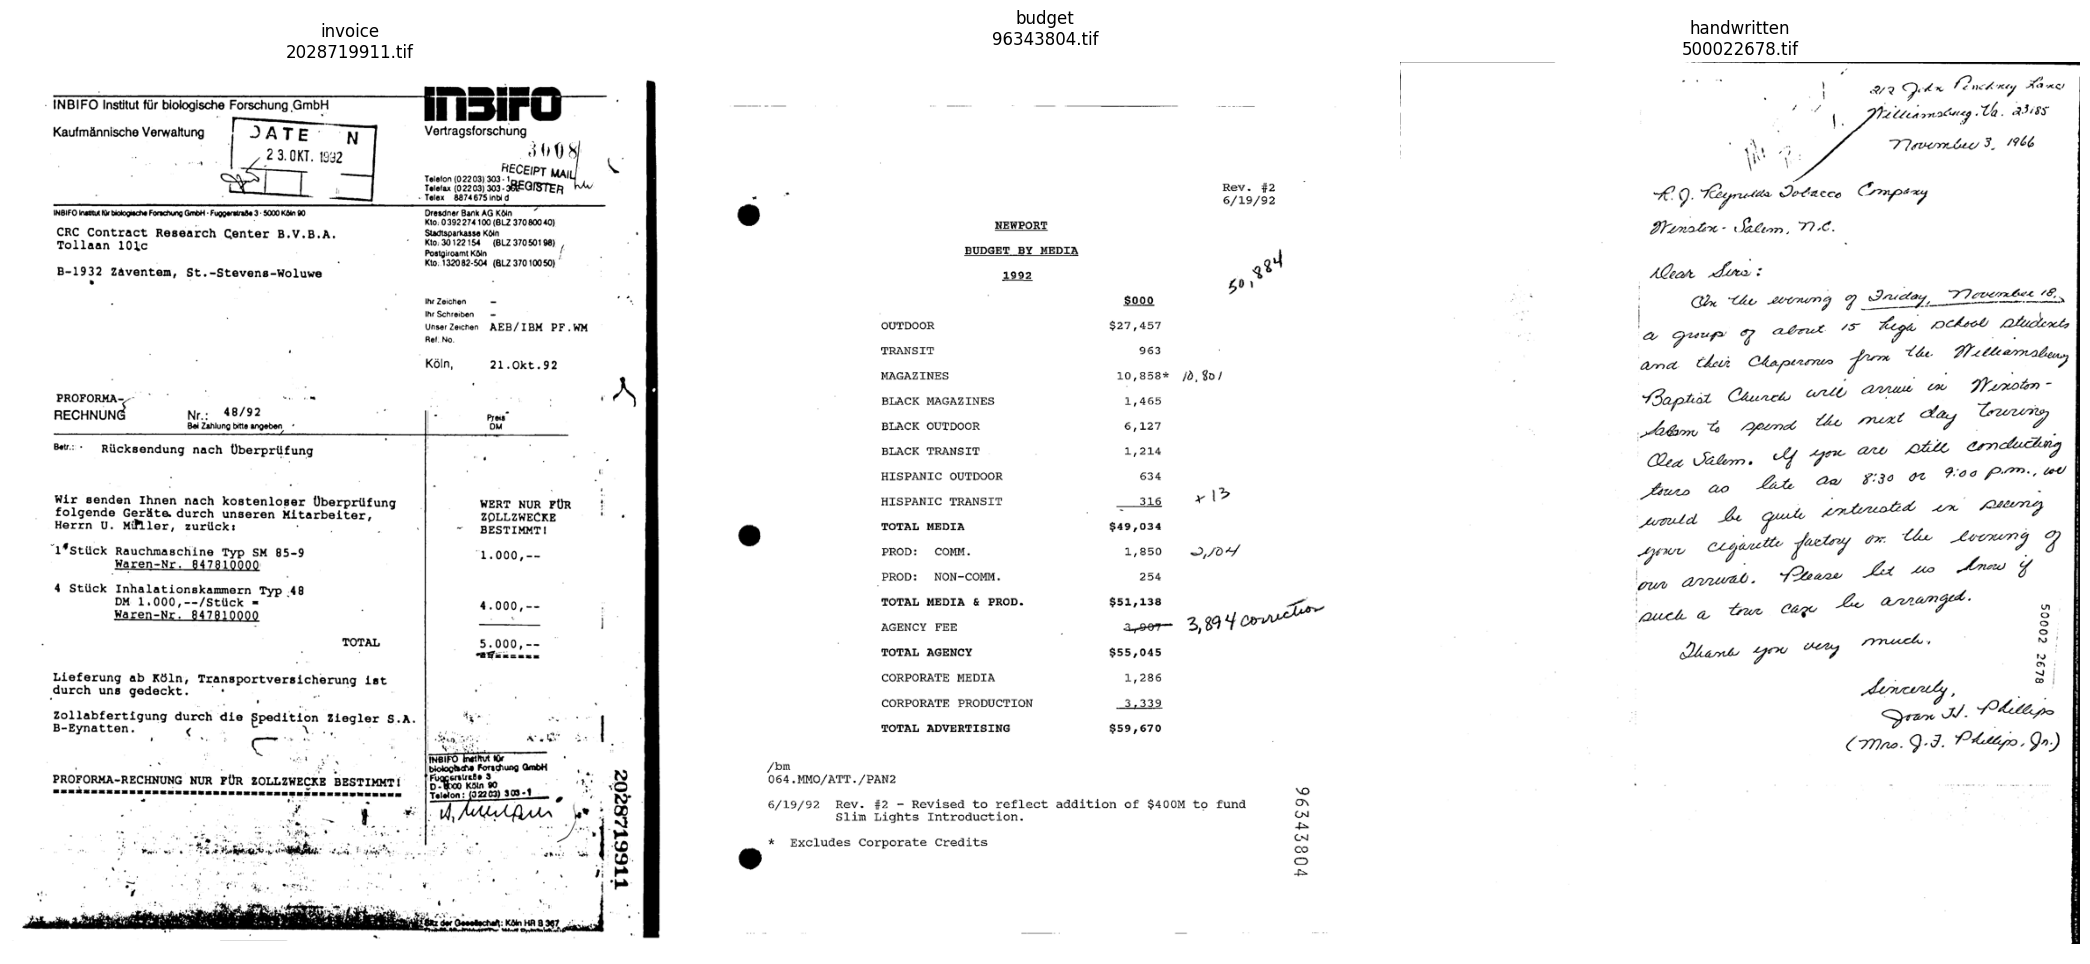

In [4]:
# ============================================================
# CELL 4 OF 6 — LOCATE THE FIXED FILES, LOAD THE IMAGES, AND PREVIEW THEM
# ============================================================
# This cell transforms the fixed manifest into actual loaded documents.
#
# Overall purpose of this cell:
# 1. Search the dataset recursively for each fixed file name.
# 2. Load the matching image into memory.
# 3. Attach the image together with its ground truth and validation targets.
# 4. Display the three selected images so the workflow is visually transparent.
#
# If one of the fixed files is missing, this cell raises an error immediately.
# That makes debugging much easier than letting later cells fail indirectly.

# Define a helper that searches the dataset recursively for one exact file name.
def find_file_by_name(dataset_root, file_name):
    # Convert the dataset root into a Path object.
    root = Path(dataset_root)
    # Walk through every folder under the dataset root.
    for current_root, dirs, files in os.walk(root):
        # Check whether the desired file name exists in the current folder.
        if file_name in files:
            # Return the full path to the matching file.
            return Path(current_root) / file_name
    # Return None if the file was not found anywhere under the dataset root.
    return None

# Define a helper that loads all fixed documents listed in the manifest.
def load_fixed_documents(dataset_root, manifest):
    # Print a visible section title.
    print_section("STEP 3 — LOCATE AND LOAD FIXED DOCUMENTS")
    # Create an empty list that will store the loaded document dictionaries.
    loaded_documents = []
    # Loop through each configured fixed sample.
    for item in manifest:
        # Search the dataset recursively for the current file name.
        file_path = find_file_by_name(dataset_root, item["file_name"])
        # Stop immediately if the file cannot be found.
        if file_path is None:
            # Raise a clear error message with the missing file name.
            raise FileNotFoundError(f"Could not find fixed sample file: {item['file_name']}")
        # Open the image file using Pillow.
        image = Image.open(file_path)
        # Build one loaded-document dictionary with all information needed later.
        document = {
            "sample_id": item["sample_id"],
            "category": item["category"],
            "title": item["display_title"],
            "file_name": item["file_name"],
            "file_path": str(file_path),
            "image": image.copy(),
            "ground_truth_text": item["ground_truth_text"],
            "target_fields": item["target_fields"]
        }
        # Add the loaded document to the output list.
        loaded_documents.append(document)
        # Print a confirmation line for the current document.
        print(f"✅ Loaded {item['category']} file: {file_path}")
    # Return the list of fully loaded documents.
    return loaded_documents

# Define a helper that shows the loaded document images side by side.
def show_document_previews(documents):
    # Print a visible section title.
    print_section("STEP 4 — PREVIEW THE THREE FIXED DOCUMENTS")
    # Create one row of plots with one column for each document.
    fig, axes = plt.subplots(1, len(documents), figsize=(7 * len(documents), 10))
    # Convert axes into a list when there is only one document.
    if len(documents) == 1:
        axes = [axes]
    # Loop through each axis and each document together.
    for ax, document in zip(axes, documents):
        # Draw the document image on the current subplot.
        ax.imshow(document["image"], cmap="gray")
        # Set the subplot title to the category and file name.
        ax.set_title(f"{document['category']}\n{document['file_name']}", fontsize=12)
        # Hide the axis ticks because they do not help for this demo.
        ax.axis("off")
    # Adjust the layout so titles and images do not overlap.
    plt.tight_layout()
    # Display the figure.
    plt.show()

# Load the fixed documents into memory.
documents = load_fixed_documents(dataset_path, FIXED_SAMPLE_MANIFEST)

# Preview the loaded document images.
show_document_previews(documents)


# Step 5 — OCR Execution on the Three Fixed Documents

## What this block does

This block implements the actual OCR pipeline. Once the notebook has the three verified document images, the next task is to convert each image into a format that can be sent to the OCR API, submit the request, and store the returned text.

The general pattern is:

1. take a PIL image,
2. normalize it into a robust format,
3. convert it into bytes,
4. encode those bytes for API transport,
5. send the OCR request, and
6. collect the extracted text.

This block is therefore the operational center of the notebook. All earlier blocks prepared the runtime, configuration, and inputs; this block is where the extraction actually happens.

## Why this block is important

Students often think of OCR as a black box, but there is a real technical pipeline between “image” and “text.” This block exposes that pipeline clearly. It shows that OCR in a modern notebook workflow often involves both image preprocessing steps and API communication steps.

The block also stores the OCR outputs together with the original document metadata, which is important because the next block needs both the extracted text and the reference ground truth in order to validate the results.

## Mini flow diagram

```text
Loaded PIL image
      ↓
Convert to API-safe image bytes
      ↓
Base64 encode image
      ↓
Send OCR request
      ↓
Receive extracted text
      ↓
Store OCR result with metadata
```


In [5]:
# ============================================================
# CELL 5 OF 6 — RUN OCR ON THE THREE FIXED DOCUMENTS
# ============================================================
# This cell implements the actual OCR pipeline.
#
# Overall purpose of this cell:
# 1. Convert each PIL image into base64-encoded PNG bytes.
# 2. Send the image to the OCR API.
# 3. Store the extracted text together with the original metadata.
#
# The OCR prompt is intentionally simple because the goal here is to
# extract text faithfully rather than ask the model for analysis.

# Define a helper that converts a Pillow image into a base64 string.
def convert_image_to_base64(image):
    # Convert the image to RGB mode for broad API compatibility.
    rgb_image = image.convert("RGB")
    # Create an in-memory byte buffer.
    buffer = io.BytesIO()
    # Save the RGB image into the buffer in PNG format.
    rgb_image.save(buffer, format="PNG")
    # Read the raw bytes from the buffer.
    image_bytes = buffer.getvalue()
    # Encode the raw bytes into a base64 string.
    image_base64 = base64.b64encode(image_bytes).decode("utf-8")
    # Return the base64 image string.
    return image_base64

# Define a helper that sends one image to the OCR API and returns the extracted text.
def run_qwen_ocr_on_image(image):
    # Convert the image to a base64 string before building the request payload.
    image_base64 = convert_image_to_base64(image)
    # Build the HTTP headers required by the OCR API.
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }
    # Build the chat-style JSON payload expected by the endpoint.
    payload = {
        "model": "qwen3-vl-plus",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": "Please perform OCR on this document image and return only the extracted text."
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        }
                    }
                ]
            }
        ]
    }
    # Send the OCR request to the remote API.
    response = requests.post(BASE_URL, headers=headers, json=payload)
    # Raise an error immediately if the API response is unsuccessful.
    response.raise_for_status()
    # Parse the returned JSON payload.
    response_json = response.json()
    # Extract the OCR text from the standard chat-completions structure.
    extracted_text = response_json["choices"][0]["message"]["content"]
    # Return the extracted text.
    return extracted_text

# Define a helper that runs OCR on all loaded documents.
def run_ocr_pipeline(documents):
    # Print a visible section title.
    print_section("STEP 5 — RUN OCR ON THE THREE FIXED DOCUMENTS")
    # Create an empty list that will store the OCR results.
    results = []
    # Loop through each loaded document.
    for document in documents:
        # Print the title of the document currently being processed.
        print(f"🔍 Running OCR for: {document['title']}")
        # Run OCR on the current document image.
        extracted_text = run_qwen_ocr_on_image(document["image"])
        # Build a result dictionary containing both OCR output and metadata.
        result = {
            "sample_id": document["sample_id"],
            "category": document["category"],
            "title": document["title"],
            "file_name": document["file_name"],
            "file_path": document["file_path"],
            "ground_truth_text": document["ground_truth_text"],
            "target_fields": document["target_fields"],
            "extracted_text": extracted_text
        }
        # Add the current OCR result to the output list.
        results.append(result)
        # Print a short preview of the OCR output for quick inspection.
        print("-" * 80)
        print(extracted_text[:1000])
        print("-" * 80)
    # Return the complete OCR result list.
    return results

# Run OCR on the three fixed documents and store the results.
ocr_results = run_ocr_pipeline(documents)



STEP 5 — RUN OCR ON THE THREE FIXED DOCUMENTS
🔍 Running OCR for: Invoice Document - 2028719911.tif
--------------------------------------------------------------------------------
INBIFO Institut für biologische Forschung GmbH  
Kaufmännische Verwaltung  

DATE N  
23.0KT. 1992  

INBIFO Institut für biologische Forschung GmbH · Fuggerstraße 3 · 5000 Köln 90  
CRC Contract Research Center B.V.B.A.  
Tollaan 101c  
B-1932 Zaventem, St.-Stevens-Woluwe  

Vertragsforschung  
3008  
RECEIPT MAIL  
REGISTER  

Telefon (02203) 303-1  
Telefax (02203) 303-366  
Telex 8874675 inbi d  

Dresdner Bank AG Köln  
Kto. 0392274100 (BLZ 37080040)  
Stadtsparkasse Köln  
Kto. 30 122 154 (BLZ 37050198)  
Postgiroamt Köln  
Kto. 132082-504 (BLZ 37010050)  

Ihr Zeichen –  
Ihr Schreiben –  
Unser Zeichen AEB / IBM PF.WM  
Ref. No.  

Köln, 21.Okt.92  

PROFORMA-  
RECHNUNG Nr.: 48/92  
Bei Zahlung bitte angeben  

Betr.: Rücksendung nach Überprüfung  

Wir senden Ihnen nach kostenloser Überprüfung  
fo

# Step 6 — Full-Document Validation for Invoice and Budget, and Field-Level Validation for Handwritten Text

## What this block does

This final block closes the notebook by turning OCR output into an interpretable evaluation result.

At this point in the notebook, the OCR model has already produced extracted text for the three fixed samples. The remaining question is no longer **“Can the model return some text?”** but rather **“How accurate is the returned text when compared with a manually prepared reference?”**

This block now uses **two different validation strategies**, because the three document types do not have the same evaluation difficulty.

### 1. Invoice and budget documents → full-document validation

For the **invoice** and **budget** samples, the images are relatively structured and the text is readable enough to support a stronger evaluation design. Therefore, for these two document types, this block uses the **manually prepared full transcription** as the ground truth and compares the OCR output against the entire reference text.

This means the notebook now evaluates:
- the overall normalized character-level similarity,
- the token-level overlap,
- the line-level coverage of the manually transcribed text,
- and a compact “overall accuracy” summary for each document.

In other words, for invoice and budget, the goal is no longer to check only a few important values such as the total amount or year. Instead, the goal is to evaluate **the entire document text**.

### 2. Handwritten document → field-level validation

The handwritten document is much harder to read, even for humans. Because of that, using the full handwritten transcription as a strict OCR benchmark would create a noisy and unfair evaluation. Therefore, for the handwritten sample, this block intentionally keeps the earlier **field-level validation** design.

This means the notebook still checks whether the OCR output correctly captures key business-relevant information such as:
- recipient,
- location,
- date,
- closing,
- and sender.

### Why this mixed design is appropriate

This mixed validation design is more realistic than forcing all document types into the same metric.

- **Structured printed documents** should be judged using stronger full-text comparison.
- **Difficult handwritten documents** should still be evaluated, but with a more tolerant key-information strategy.

That design reflects real OCR practice in business settings:
- clean printed forms can be evaluated more strictly,
- while messy handwritten content often requires more flexible validation rules.

---

## Global Input of this block

This block uses the following already-created objects:

- `ocr_results`  
  The real OCR outputs generated in Step 5.

- `ground_truth_text`  
  The manually prepared full transcription stored in the fixed sample manifest.

- `target_fields`  
  The field-level reference values, used only for the handwritten document.

---

## Global Output of this block

This block produces four kinds of outputs:

1. **Document-level evaluation records**  
   A structured summary for each sample.

2. **Full-text comparison table for invoice and budget**  
   This shows OCR output, manual ground truth, and the overall accuracy metrics.

3. **Field-level validation table for the handwritten sample**  
   This keeps the handwritten evaluation interpretable and fair.

4. **Readable printed report**  
   A human-readable narrative summary of the OCR quality.

---

## Input → Output Schematic for This Final Step

```text
Manual Ground Truth + OCR Output
                │
                ▼
 ┌──────────────────────────────────────┐
 │ Invoice / Budget → Full-Text Compare │
 │  • Character similarity              │
 │  • Token overlap                     │
 │  • Line coverage                     │
 │  • Overall accuracy                  │
 └──────────────────────────────────────┘
                │
                ├──────────────┐
                │              │
                ▼              ▼
 ┌───────────────────────┐   ┌───────────────────────────┐
 │ Handwritten Document  │   │ Final Structured Outputs  │
 │ → Field Validation    │   │ • summary table           │
 │ • key fields only     │   │ • comparison table        │
 │ • tolerant checking   │   │ • handwritten field table │
 └───────────────────────┘   └───────────────────────────┘
```

---

## What students should focus on here

When reading this block, the most important idea is that **evaluation design should match document type**.

The printed invoice and budget are suitable for **whole-document OCR accuracy measurement**, while the handwritten letter is better evaluated through **key information extraction**.

That distinction is important because OCR quality is not always best measured using one universal rule. Good evaluation should reflect:
- document structure,
- text readability,
- and the practical business objective.

---


In [6]:
# ============================================================
# CELL 6 OF 6 — VALIDATE OCR OUTPUT AND BUILD THE FINAL REPORT
# ============================================================
# This cell performs the final evaluation stage of the notebook.
#
# Overall purpose of this cell:
# 1. Use full-document validation for the invoice and budget samples.
# 2. Keep field-level validation for the handwritten sample.
# 3. Compute interpretable OCR accuracy metrics.
# 4. Build structured summary tables.
# 5. Print a readable report that explains the OCR quality.

import numpy as np
# Define a helper that tokenizes text in a simple and stable way.
def tokenize_basic(text):
    # Normalize the text first so OCR formatting differences are reduced.
    normalized_text = normalize_text(text)
    # Replace non-alphanumeric characters with spaces to create clean token boundaries.
    cleaned_text = re.sub(r"[^a-z0-9\.]+", " ", normalized_text)
    # Split the cleaned text into tokens and remove empty items.
    tokens = [token for token in cleaned_text.split() if token]
    # Return the final token list.
    return tokens

# Define a helper that splits text into normalized non-empty lines.
def normalize_lines(text):
    # Split the raw text into individual lines.
    raw_lines = text.splitlines()
    # Normalize each line and keep only lines that still contain visible content.
    normalized_lines = [normalize_text(line) for line in raw_lines if normalize_text(line)]
    # Return the cleaned line list.
    return normalized_lines

# Define a helper that computes full-document OCR accuracy metrics.
def compute_full_text_metrics(ocr_text, ground_truth_text):
    # Normalize the OCR text for tolerant comparison.
    normalized_ocr_text = normalize_text(ocr_text)
    # Normalize the manual ground-truth text for tolerant comparison.
    normalized_ground_truth_text = normalize_text(ground_truth_text)

    # Compute a character-level similarity score using a sequence matcher.
    character_accuracy = SequenceMatcher(None, normalized_ocr_text, normalized_ground_truth_text).ratio()

    # Tokenize both texts.
    ocr_tokens = tokenize_basic(ocr_text)
    # Tokenize the ground-truth text.
    ground_truth_tokens = tokenize_basic(ground_truth_text)

    # Convert both token lists into sets for overlap analysis.
    ocr_token_set = set(ocr_tokens)
    # Convert the ground-truth tokens into a set.
    ground_truth_token_set = set(ground_truth_tokens)

    # Count the number of shared unique tokens.
    shared_token_count = len(ocr_token_set & ground_truth_token_set)

    # Compute token precision: how much of the OCR vocabulary is correct.
    token_precision = shared_token_count / len(ocr_token_set) if ocr_token_set else 0.0
    # Compute token recall: how much of the ground-truth vocabulary is covered by OCR.
    token_recall = shared_token_count / len(ground_truth_token_set) if ground_truth_token_set else 0.0

    # Compute token F1 for a balanced summary of precision and recall.
    if token_precision + token_recall == 0:
        # Return zero when both precision and recall are zero.
        token_f1 = 0.0
    else:
        # Compute the harmonic mean of token precision and token recall.
        token_f1 = 2 * token_precision * token_recall / (token_precision + token_recall)

    # Normalize both texts into line lists.
    ocr_lines = normalize_lines(ocr_text)
    # Normalize the manual ground-truth text into line lists.
    ground_truth_lines = normalize_lines(ground_truth_text)

    # Count how many ground-truth lines are substantially recovered by OCR.
    matched_line_count = 0
    # Loop through each normalized ground-truth line one by one.
    for ground_truth_line in ground_truth_lines:
        # Mark the line as recovered if the full line appears in one OCR line,
        # or if one normalized line is contained inside the other.
        if any(
            ground_truth_line == ocr_line or
            ground_truth_line in ocr_line or
            ocr_line in ground_truth_line
            for ocr_line in ocr_lines
        ):
            # Increase the recovered-line counter by one.
            matched_line_count += 1
    # Compute line recall as the fraction of reference lines recovered by OCR.
    line_recall = matched_line_count / len(ground_truth_lines) if ground_truth_lines else 0.0

    # Combine several metrics into one simple overall accuracy score.
    overall_accuracy = (
        0.50 * character_accuracy +
        0.30 * token_f1 +
        0.20 * line_recall
    )

    # Return all computed metrics in a structured dictionary.
    return {
        "character_accuracy": character_accuracy,
        "token_precision": token_precision,
        "token_recall": token_recall,
        "token_f1": token_f1,
        "line_recall": line_recall,
        "overall_accuracy": overall_accuracy
    }

# Define a helper that validates important handwritten fields one by one.
def validate_handwritten_fields(ocr_text, target_fields):
    # Create an empty list that will store field-level validation records.
    field_results = []
    # Normalize the OCR text once so repeated comparisons are cleaner.
    normalized_ocr_text = normalize_text(ocr_text)
    # Normalize a number-friendly version of the OCR text as well.
    normalized_ocr_number_text = normalize_number(ocr_text)

    # Loop through each named target field and expected value.
    for field_name, expected_value in target_fields.items():
        # Normalize the expected value for tolerant text matching.
        normalized_expected_text = normalize_text(expected_value)
        # Normalize the expected value in number form too.
        normalized_expected_number = normalize_number(expected_value)

        # Check whether the expected text appears directly in the OCR output.
        text_match = normalized_expected_text in normalized_ocr_text
        # Check whether the normalized numeric form appears in the OCR output.
        number_match = normalized_expected_number in normalized_ocr_number_text

        # Combine both checks into one field-level pass flag.
        field_passed = text_match or number_match

        # Store the field-level result as a structured record.
        field_results.append({
            "field_name": field_name,
            "expected_value": expected_value,
            "passed": field_passed
        })

    # Return the field-level validation list.
    return field_results

# Define a helper that validates one document according to its category.
def validate_single_result(result):
    # Extract the category so the function can choose the right validation strategy.
    category = result["category"]

    # Route invoice and budget documents to the full-text validation path.
    if category in ["invoice", "budget"]:
        # Compute full-document OCR accuracy metrics.
        full_text_metrics = compute_full_text_metrics(
            result["extracted_text"],
            result["ground_truth_text"]
        )

        # Build the final validation summary for the printed document.
        return {
            "sample_id": result["sample_id"],
            "category": category,
            "title": result["title"],
            "validation_mode": "full_text",
            "character_accuracy": full_text_metrics["character_accuracy"],
            "token_precision": full_text_metrics["token_precision"],
            "token_recall": full_text_metrics["token_recall"],
            "token_f1": full_text_metrics["token_f1"],
            "line_recall": full_text_metrics["line_recall"],
            "overall_accuracy": full_text_metrics["overall_accuracy"],
            "ocr_text": result["extracted_text"],
            "ground_truth_text": result["ground_truth_text"],
            "field_results": []
        }

    # Route the handwritten document to the field-level validation path.
    if category == "handwritten":
        # Validate the handwritten key fields only.
        field_results = validate_handwritten_fields(
            result["extracted_text"],
            result["target_fields"]
        )

        # Count how many fields passed.
        passed_fields = sum(item["passed"] for item in field_results)
        # Count how many fields exist in total.
        total_fields = len(field_results)
        # Compute a simple handwritten field-level accuracy score.
        overall_accuracy = passed_fields / total_fields if total_fields else 0.0

        # Build the handwritten validation summary.
        return {
            "sample_id": result["sample_id"],
            "category": category,
            "title": result["title"],
            "validation_mode": "field_only",
            "character_accuracy": np.nan,
            "token_precision": np.nan,
            "token_recall": np.nan,
            "token_f1": np.nan,
            "line_recall": np.nan,
            "overall_accuracy": overall_accuracy,
            "passed_fields": passed_fields,
            "total_fields": total_fields,
            "ocr_text": result["extracted_text"],
            "ground_truth_text": result["ground_truth_text"],
            "field_results": field_results
        }

    # Raise an error if an unexpected category appears.
    raise ValueError(f"Unsupported category for validation: {category}")

# Define a helper that validates every OCR result in the notebook.
def validate_all_results(ocr_results):
    # Create an empty list that will store the validation summary for each document.
    validation_results = []
    # Loop through every OCR result.
    for result in ocr_results:
        # Validate the current OCR result using the category-specific strategy.
        document_summary = validate_single_result(result)
        # Append the validation summary to the output list.
        validation_results.append(document_summary)
    # Return all document-level validation results.
    return validation_results

# Define a helper that builds the main summary tables shown at the end.
def build_summary_tables(validation_results):
    # Create an empty list for document-level summary rows.
    document_rows = []
    # Create an empty list for full-text comparison rows.
    full_text_rows = []
    # Create an empty list for handwritten field-level rows.
    handwritten_field_rows = []

    # Loop through each validation result.
    for item in validation_results:
        # Build one document-level summary row.
        document_rows.append({
            "title": item["title"],
            "category": item["category"],
            "validation_mode": item["validation_mode"],
            "character_accuracy": round(item["character_accuracy"], 3) if pd.notna(item["character_accuracy"]) else np.nan,
            "token_precision": round(item["token_precision"], 3) if pd.notna(item["token_precision"]) else np.nan,
            "token_recall": round(item["token_recall"], 3) if pd.notna(item["token_recall"]) else np.nan,
            "token_f1": round(item["token_f1"], 3) if pd.notna(item["token_f1"]) else np.nan,
            "line_recall": round(item["line_recall"], 3) if pd.notna(item["line_recall"]) else np.nan,
            "overall_accuracy": round(item["overall_accuracy"], 3),
            "passed_fields": item.get("passed_fields", np.nan),
            "total_fields": item.get("total_fields", np.nan)
        })

        # For invoice and budget, build a full-text comparison row.
        if item["validation_mode"] == "full_text":
            full_text_rows.append({
                "title": item["title"],
                "category": item["category"],
                "manual_ground_truth": item["ground_truth_text"],
                "ocr_output": item["ocr_text"],
                "character_accuracy": round(item["character_accuracy"], 3),
                "token_precision": round(item["token_precision"], 3),
                "token_recall": round(item["token_recall"], 3),
                "token_f1": round(item["token_f1"], 3),
                "line_recall": round(item["line_recall"], 3),
                "overall_accuracy": round(item["overall_accuracy"], 3)
            })

        # For the handwritten document, build one row per field.
        if item["validation_mode"] == "field_only":
            for field_result in item["field_results"]:
                handwritten_field_rows.append({
                    "title": item["title"],
                    "field_name": field_result["field_name"],
                    "expected_value": field_result["expected_value"],
                    "passed": field_result["passed"]
                })

    # Convert the document-level rows into a pandas DataFrame.
    document_summary_df = pd.DataFrame(document_rows)
    # Convert the invoice/budget full-text rows into a pandas DataFrame.
    full_text_comparison_df = pd.DataFrame(full_text_rows)
    # Convert the handwritten field rows into a pandas DataFrame.
    handwritten_field_df = pd.DataFrame(handwritten_field_rows)

    # Return the three summary tables.
    return document_summary_df, full_text_comparison_df, handwritten_field_df

# Define a helper that prints a readable report for all documents.
def print_readable_report(validation_results):
    # Print a visible section title for the final report.
    print_section("STEP 6 — FINAL VALIDATION REPORT")

    # Loop through each validated document.
    for item in validation_results:
        # Print the document title.
        print(f"📄 {item['title']}")
        # Print the document category.
        print(f"Category: {item['category']}")
        # Print the validation mode used for the document.
        print(f"Validation mode: {item['validation_mode']}")

        # Print the full-text metrics for invoice and budget.
        if item["validation_mode"] == "full_text":
            # Print the full-document character-level accuracy.
            print(f"Character accuracy: {item['character_accuracy']:.3f}")
            # Print token precision.
            print(f"Token precision: {item['token_precision']:.3f}")
            # Print token recall.
            print(f"Token recall: {item['token_recall']:.3f}")
            # Print token F1.
            print(f"Token F1: {item['token_f1']:.3f}")
            # Print line-level recall.
            print(f"Line recall: {item['line_recall']:.3f}")
            # Print the weighted overall accuracy.
            print(f"Overall OCR accuracy: {item['overall_accuracy']:.3f}")

        # Print the handwritten field summary for the handwritten sample.
        if item["validation_mode"] == "field_only":
            # Print the number of handwritten fields that passed.
            print(f"Field accuracy: {item['passed_fields']}/{item['total_fields']} fields passed")
            # Print a short field-level breakdown header.
            print("Field details:")
            # Loop through each field result and print one line.
            for field_result in item["field_results"]:
                # Choose a visible pass/fail mark.
                mark = "✅" if field_result["passed"] else "❌"
                # Print the field-level result.
                print(f"  {mark} {field_result['field_name']}: {field_result['expected_value']}")

        # Print a separator line after each document.
        print("-" * 100)

# Validate the real OCR outputs generated in Cell 5.
validation_results = validate_all_results(ocr_results)
# Print the readable document-by-document report.
print_readable_report(validation_results)


STEP 6 — FINAL VALIDATION REPORT
📄 Invoice Document - 2028719911.tif
Category: invoice
Validation mode: full_text
Character accuracy: 0.643
Token precision: 0.636
Token recall: 0.978
Token F1: 0.771
Line recall: 0.871
Overall OCR accuracy: 0.727
----------------------------------------------------------------------------------------------------
📄 Budget Document - 96343804.tif
Category: budget
Validation mode: full_text
Character accuracy: 0.498
Token precision: 0.893
Token recall: 1.000
Token F1: 0.944
Line recall: 0.808
Overall OCR accuracy: 0.694
----------------------------------------------------------------------------------------------------
📄 Handwritten Document - 500022678.tif
Category: handwritten
Validation mode: field_only
Field accuracy: 3/5 fields passed
Field details:
  ❌ recipient: R. J. Reynolds Tobacco Company
  ✅ location: Winston-Salem, N.C.
  ✅ date: November 3, 1966
  ✅ closing: Sincerely
  ❌ sender: Joan H. Phillips
---------------------------------------------

In [7]:
# Build the three summary tables used in the final display section.
document_summary_df, full_text_comparison_df, handwritten_field_df = build_summary_tables(validation_results)

In [8]:

# Print a visible title before displaying the document-level summary.
print_section("DOCUMENT-LEVEL SUMMARY TABLE")
# Display the document-level summary table.
display(document_summary_df)


DOCUMENT-LEVEL SUMMARY TABLE


,title,category,validation_mode,character_accuracy,token_precision,token_recall,token_f1,line_recall,overall_accuracy,passed_fields,total_fields
0,Invoice Document - 2028719911.tif,invoice,full_text,0.643,0.636,0.978,0.771,0.871,0.727,NaN,NaN
1,Budget Document - 96343804.tif,budget,full_text,0.498,0.893,1.000,0.944,0.808,0.694,NaN,NaN
2,Handwritten Document - 500022678.tif,handwritten,field_only,NaN,NaN,NaN,NaN,NaN,0.600,3.0,5.0


In [9]:
# Print a visible title before displaying the invoice and budget full-text comparison table.
print_section("FULL-TEXT COMPARISON TABLE — INVOICE AND BUDGET")
# Display the full-text comparison table.
display(full_text_comparison_df)


FULL-TEXT COMPARISON TABLE — INVOICE AND BUDGET


,title,category,manual_ground_truth,ocr_output,character_accuracy,token_precision,token_recall,token_f1,line_recall,overall_accuracy
0,Invoice Document - 2028719911.tif,invoice,INBIFO Institut für biologische Forschung GmbH...,INBIFO Institut für biologische Forschung GmbH...,0.643,0.636,0.978,0.771,0.871,0.727
1,Budget Document - 96343804.tif,budget,NEWPORT\n BUDGE...,NEWPORT \nBUDGET BY MEDIA \n1992 \n\n$000 ...,0.498,0.893,1.000,0.944,0.808,0.694


In [10]:
# Print a visible title before displaying the handwritten field-level validation table.
print_section("HANDWRITTEN FIELD-LEVEL VALIDATION TABLE")
# Display the handwritten field-level validation table.
display(handwritten_field_df)


HANDWRITTEN FIELD-LEVEL VALIDATION TABLE


,title,field_name,expected_value,passed
0,Handwritten Document - 500022678.tif,recipient,R. J. Reynolds Tobacco Company,False
1,Handwritten Document - 500022678.tif,location,"Winston-Salem, N.C.",True
2,Handwritten Document - 500022678.tif,date,"November 3, 1966",True
3,Handwritten Document - 500022678.tif,closing,Sincerely,True
4,Handwritten Document - 500022678.tif,sender,Joan H. Phillips,False
